[78 96 27 21 80 83 52 15 84 52 16 14 42 69 41 85  1 43 53 96 24 83  8 34
 75 58 94 76 92 83 14 94 85 15 98 75 32 14 39 91 79 23 50 86 65 31 12 97
 24 52 70 33 52 29 84 61 18 34 69 68 32 16 15 25 79 87 35 61 50 27 54 15
 49 14 25 25  3 39 73 65 78 84  7 78 12 34  9 15 49 46 36 44 43 58 63 38
 76 64 49 12]


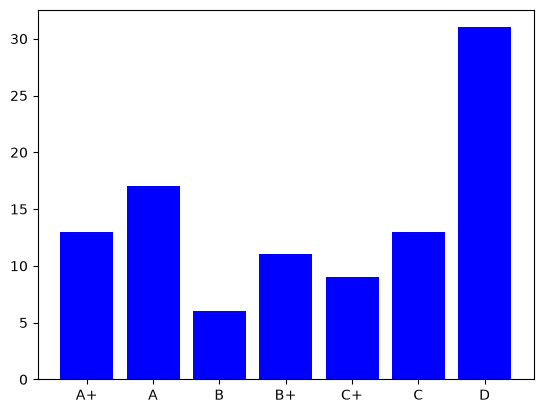

In [17]:
import json
import numpy as np
import matplotlib.pyplot as plt
class StudentAnalyzer:
    def __init__(self):
        pass

    """
    def generate_function(self):
        rng = np.random.default_rng(1)
        scores = rng.integers(1,100,size=100)
        print(scores)
    """
    def assing_grades(self,scores):

        condition  = [
            (scores>=90) & (scores <=100),
            (scores>=80) & (scores <=89),
            (scores >=70) & (scores <=79),
            (scores >=60)  & (scores <=69),
            (scores >=45) & (scores <=59),
            (scores >= 33) & (scores <=44),
            (scores >=0) & (scores <33)
        ]
        choice = ["A+","A","B","B+","C+","C","D"]

        grades = np.select(condition,choice,default = 'Invalid')
        print(grades)


    def calculate_statistics(self,scores):
        print("mean: ",np.mean(scores))
        print("median: ",np.median(scores))
        print("std: ",np.std(scores))
        print("variance: ",np.var(scores))
        marks = int(input("Enter Marks To Find the your percentile"))
        print("percentiles: ",np.percentile(scores,q=marks))

    def filter_top_performers(self,scores):
        top_marks = scores[(scores>=90) & (scores<=100)]
        print("Top Marks:",top_marks)

    def filter_strugglings(self,scores):
        strugggers = scores[(scores>=0) & (scores<=40)]
        print("Strugglers: ",strugggers)

    def grade_distribution(self,choice,grades):
        with open("data.json","r") as file:
            loaded_data = json.load(file)
        count = 0
        for grade in choice:
            indicies = np.argwhere(grade==grades)
            count = len(indicies)
            percentage = (count/100) * 100
            loaded_data["distribution"].append({
                "grade":grade,
                "count":count,
                "percentage":percentage
            })
            print(loaded_data)
        with open("data.json","w") as file:
            json.dump(loaded_data,file,indent=4)
            
    def display_grade_breakdown(self):
        value = []
        percentages = []
        with open("data.json","r") as file:
            loaded_data = json.load(file)

        for i in range(0,len(loaded_data["distribution"])):
            value.append(loaded_data["distribution"][i]["grade"])
            percentages.append(loaded_data["distribution"][i]["percentage"])

        plt.bar(value,percentages,color = "blue")

    def find_top_n_student(self,scores,n):
        sorted_scores = np.sort(scores)
        sorted_scores = sorted_scores[::-1]
        for i in range(n):
            print(sorted_scores[i])


    def find_bottom_n_students(self,n,scores):
        sorted_scores_2 = np.sort(scores)
        for i in range(n):
            print(sorted_scores_2[i])

    def calculate_pass_percentage(self,scores):
        passed_scores = scores[scores>=35]
        pass_percentage = (len(passed_scores) / len(scores)) * 100
        print(pass_percentage)


    def display_score_histogram(self,scores):
        passed_scores = scores[scores>=35]
        plt.hist(passed_scores, color="yellow")

    def correlation(self):
        pass


rng = np.random.default_rng(10)
scores = rng.integers(1,101,size=100)
print(scores)

section1 = StudentAnalyzer()
section1.display_grade_breakdown()